Import Required Libraries

In [4]:
import pandas as pd
import numpy as np

from xgboost import XGBClassifier

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns



In [5]:
tasks = pd.read_csv("../data/processed/tasks_processed.csv")

tasks.head()

,Task_ID,Task_Title,Task_Description,Category,Priority,Status,Project_Name,Module,Sprint,Story_Points,Created_Date,Due_Date,Estimated_Hours,Actual_Hours,Assigned_To,Environment,Severity,Labels,SLA_Hours,Completion_Status
0,TASK-10001,Support: Investigate Payments,House answer start behind old travel Democrat ...,Support,Medium,Review,Apollo,Security,Sprint 7,1,2025-03-02,2025-03-08,2,1,EMP020,Development,Minor,support,96,Yes
1,TASK-10002,Documentation: Implement UI,Way officer however wish another teach face ce...,Documentation,Medium,Open,Vertex,Authentication,Sprint 8,1,2025-10-12,2025-10-16,2,1,EMP024,Production,Minor,documentation,48,No
2,TASK-10003,Enhancement: Fix UI,Recognize each off modern themselves role expl...,Enhancement,Low,Completed,Nova,Reporting,Sprint 4,3,2025-02-13,2025-03-04,6,6,EMP281,Production,Minor,enhancement,24,Yes
3,TASK-10004,UI/UX: Improve Notifications,Of then finish receive organization oil lay st...,UI/UX,Medium,Completed,Titan,Reporting,Sprint 10,8,2025-11-09,2025-11-17,16,20,EMP128,Development,Minor,ui-ux,48,No
4,TASK-10005,Testing: Improve UI,Can easy hospital the ball last near third sta...,Testing,Medium,Open,Phoenix,Security,Sprint 14,3,2024-08-21,2024-09-08,6,11,EMP085,UAT,Minor,testing,48,Yes


In [6]:
print(tasks.columns.tolist())

['Task_ID', 'Task_Title', 'Task_Description', 'Category', 'Priority', 'Status', 'Project_Name', 'Module', 'Sprint', 'Story_Points', 'Created_Date', 'Due_Date', 'Estimated_Hours', 'Actual_Hours', 'Assigned_To', 'Environment', 'Severity', 'Labels', 'SLA_Hours', 'Completion_Status']


In [7]:
tasks["Task_Duration"] = (
    pd.to_datetime(tasks["Due_Date"]) -
    pd.to_datetime(tasks["Created_Date"])
).dt.days

In [8]:
tasks[["Created_Date", "Due_Date", "Task_Duration"]].head()

,Created_Date,Due_Date,Task_Duration
0,2025-03-02,2025-03-08,6
1,2025-10-12,2025-10-16,4
2,2025-02-13,2025-03-04,19
3,2025-11-09,2025-11-17,8
4,2024-08-21,2024-09-08,18


In [9]:
model_df = tasks[[
    "Category",
    "Module",
    "Sprint",
    "Project_Name",
    "Environment",
    "Severity",
    "Story_Points",
    "Estimated_Hours",
    "SLA_Hours",
    "Task_Duration",
    "Priority"
]]

In [10]:
model_df.head()
model_df.shape

(10000, 11)

In [ ]:
from sklearn.preprocessing import LabelEncoder

label_encoders = {}

categorical_cols = [
    "Category",
    "Module",
    "Sprint",
    "Project_Name",
    "Environment",
    "Severity",
    "Priority"
]

for col in categorical_cols:
    le = LabelEncoder()
    model_df[col] = le.fit_transform(model_df[col])
    label_encoders[col] = le

model_df.head()

Split Features and Target

In [12]:
X = model_df.drop("Priority", axis=1)
y = model_df["Priority"]

print(X.shape)
print(y.shape)

(10000, 10)
(10000,)


Train-Test Split

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Shape :", X_train.shape)
print("Testing Shape  :", X_test.shape)

Training Shape : (8000, 10)
Testing Shape  : (2000, 10)


Train the Model

In [14]:
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    objective="multi:softmax",
    num_class=4,
    random_state=42,
    eval_metric="mlogloss"
)

xgb_model.fit(X_train, y_train)

print("XGBoost model trained successfully!")

XGBoost model trained successfully!


Make Predictions

In [15]:
y_pred = xgb_model.predict(X_test)

Evaluate the Model

In [16]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="weighted")
recall = recall_score(y_test, y_pred, average="weighted")
f1 = f1_score(y_test, y_pred, average="weighted")

print("="*60)
print("XGBoost Classifier")
print("="*60)
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

print("\nClassification Report")
print(classification_report(y_test, y_pred))

XGBoost Classifier
Accuracy : 0.838
Precision: 0.7761185685670723
Recall   : 0.838
F1 Score : 0.7952436615198089

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       234
           1       1.00      1.00      1.00       625
           2       0.19      0.04      0.07       286
           3       0.75      0.94      0.83       855

    accuracy                           0.84      2000
   macro avg       0.73      0.75      0.73      2000
weighted avg       0.78      0.84      0.80      2000



Plot Confusion Matrix

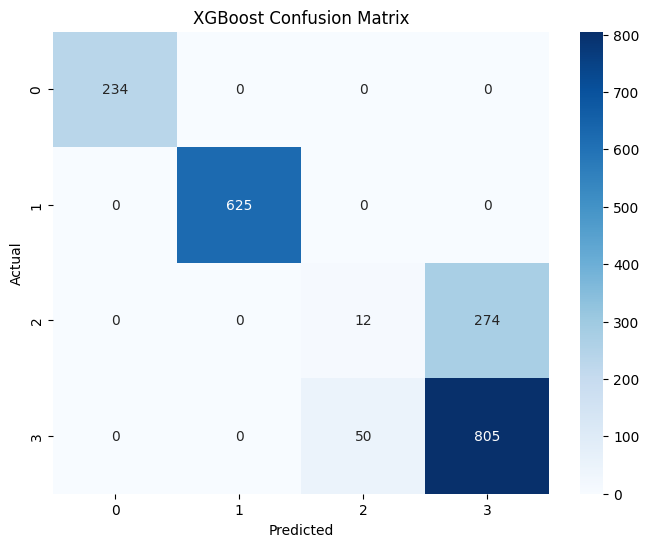

In [20]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig("../outputs/charts/xgboost_confusion_matrix.png")

plt.show()

In [18]:
import joblib

joblib.dump(
    xgb_model,
    "../models/xgboost_priority_model.pkl"
)

print("XGBoost model saved successfully!")

XGBoost model saved successfully!


In [19]:
import os

print(os.listdir("../models"))

['.gitkeep', 'label_encoders.pkl', 'random_forest_gridsearch.pkl', 'random_forest_priority_model.pkl', 'xgboost_priority_model.pkl']


In [21]:
import pandas as pd

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
5,Severity,0.955632
4,Environment,0.005909
1,Module,0.005688
3,Project_Name,0.005527
8,SLA_Hours,0.005497
2,Sprint,0.005458
0,Category,0.005448
9,Task_Duration,0.005444
6,Story_Points,0.005396
7,Estimated_Hours,0.000000


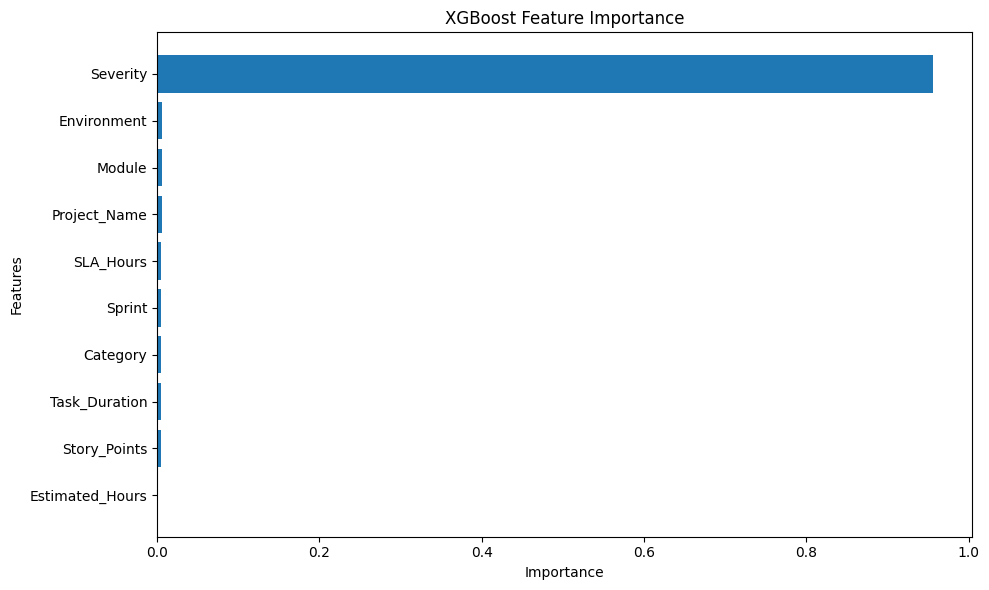

In [22]:
plt.figure(figsize=(10,6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.gca().invert_yaxis()

plt.title("XGBoost Feature Importance")

plt.xlabel("Importance")
plt.ylabel("Features")

plt.tight_layout()

plt.savefig("../outputs/charts/xgboost_feature_importance.png")

plt.show()

Two machine learning algorithms, Random Forest and XGBoost, were implemented for task priority prediction. Hyperparameter tuning was performed on the Random Forest model using GridSearchCV, resulting in an optimized model with an accuracy of 85.35%. The XGBoost classifier achieved an accuracy of 83.80%. Based on the comparison of Accuracy, Precision, Recall, and F1-score, the optimized Random Forest model was selected as the final priority prediction model due to its superior performance.